<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/tutorials/fields-3d-tutorial.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# Tutorial: accretion rates (mass flux)

# **LOAD A 3D SIMULATION, TAKE 2D SLICES AND INTERPOLATE**

This tutorial shows how to work with 3D FARGOpy fields using both Cartesian and spherical coordinates.

We will cover:

- Loading a 3D precomputed simulation.
- Defining physical unit conversions.
- Loading 2D slices from a 3D mesh.
- Interpolating 2D slices in Cartesian and spherical coordinates.
- Loading the full 3D mesh.
- Performing 3D interpolation in Cartesian and spherical coordinates.
- Adding streamlines on 2D slices using the Cartesian velocity field.


In [1]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt

try:
    import pyvista as pv
    PYVISTA_AVAILABLE = True
except Exception:
    PYVISTA_AVAILABLE = False

%load_ext autoreload
%autoreload 2


Running FARGOpy version 1.2.0.
NOTE: Since alpha versions (<=0.X.X) a major refactor has been done in versions 1.1.X.
Please check the documentation for more information.


## 1. Load a 3D simulation

For this tutorial we use the precomputed 3D Jovian-planet simulation `p3disoj`.

You can replace this with your own output directory:

```python
sim = fp.Simulation(output_dir='/path/to/your/output')
```


In [2]:
dir = fp.Simulation.download_precomputed("p3disoj")
sim = fp.Simulation(output_dir=dir)


Precomputed output directory '/tmp/p3disoj' already exist
Your simulation is now connected with '/home/fargopy/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


## 2. Define physical units

If your simulation was compiled with `UNITS=0 RESCALE=0`, you can define the conversion factors from code units to physical units.

For example, if:

- `R0 = 1.0` corresponds to 5.8 AU in CGS units
- `MSTAR = 1.0` corresponds to 1 $M_{\odot}$

then the base length and mass units are:


In [7]:
sim.units('CGS')

UL_cgs = 5.8 * sim.AU
UM_cgs = 1.0 * sim.MSUN
G_cgs = sim.GCONST

sim.set_units(UM=UM_cgs, UL=UL_cgs)

UL = sim.UL                 # length unit [cm]
UM = sim.UM                 # mass unit [g]
UT = sim.UT                 # time unit [s]
URHO = sim.URHO             # volume density unit [g cm^-3]
USIGMA = sim.USIGMA         # surface density unit [g cm^-2]
UEPS = sim.UEPS             # energy density unit [erg cm^-3]
UV = sim.UV                 # velocity unit [cm s^-1]

print(f"UL = {UL/sim.AU:.3f} AU")
print(f"UT = {UT/sim.YEAR:.3e} yr")
print(f"URHO = {URHO:.3e} g cm^-3")
print(f"UV = {UV*1e-5:.3e} km s^-1")


Units set to CGS.
UL = 5.800 AU
UT = 2.223e+00 yr
URHO = 3.045e-09 g cm^-3
UV = 1.237e+01 km s^-1


## 3. Coordinate convention

The mesh-variable convention follows the FARGO3D coordinate convention.

For 3D spherical outputs:

- Spherical coordinates: `var1 = phi`, `var2 = r`, `var3 = theta`
- Cartesian coordinates: `var1 = x`, `var2 = y`, `var3 = z`

Here `theta` is the colatitude. The midplane is usually close to `theta = pi/2`.


## 4. Load a 2D slice from the 3D simulation

To load a 2D slice, define one coordinate as a fixed value. The slice is given in code units.

For example, a midplane slice is:

```python
slice = 'theta=pi/2,r=[0.6,1.4],phi=[-pi/8,pi/8]'
```

This keeps a radial and azimuthal region and fixes `theta` at the midplane.


In [8]:
SNAP = 4
fields = ['gasdens', 'gasv', 'gasenergy']

slice_midplane = 'theta=pi/2,r=[0.6,1.4],phi=[-pi/8,pi/8]'

fields_spherical_slice = sim.load_field(
    fields=fields,
    snapshot=SNAP,
    slice=slice_midplane,
    coords='spherical',
)

fields_cartesian_slice = sim.load_field(
    fields=fields,
    snapshot=SNAP,
    slice=slice_midplane,
    coords='cartesian',
)


## 5. Plot the original 2D slice

The loaded slice contains the original mesh values. No interpolation has been applied yet.


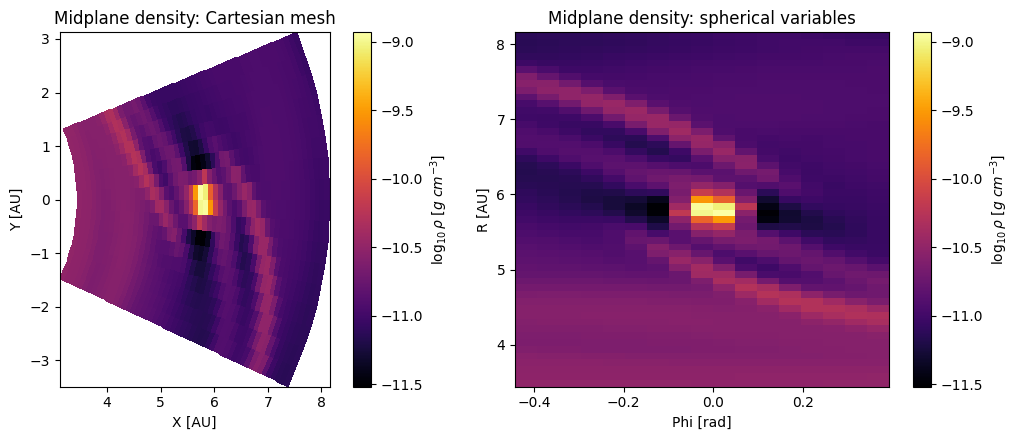

In [9]:
PHI = fields_spherical_slice.var1_mesh[0]
R = fields_spherical_slice.var2_mesh[0]
THETA = fields_spherical_slice.var3_mesh[0]

X = fields_cartesian_slice.var1_mesh[0]
Y = fields_cartesian_slice.var2_mesh[0]
Z = fields_cartesian_slice.var3_mesh[0]

RHO = fields_cartesian_slice.gasdens_mesh[0]
RHO_units = RHO * URHO

R_units = R * UL / sim.AU
X_units = X * UL / sim.AU
Y_units = Y * UL / sim.AU

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = ax[0].pcolormesh(
    X_units,
    Y_units,
    np.log10(RHO_units),
    shading='auto',
    cmap='inferno',
)
ax[0].set_xlabel('X [AU]')
ax[0].set_ylabel('Y [AU]')
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_title('Midplane density: Cartesian mesh')
fig.colorbar(im0, ax=ax[0], label=r'$\log_{10}\rho~[g~cm^{-3}]$')

im1 = ax[1].pcolormesh(
    PHI,
    R_units,
    np.log10(RHO_units),
    shading='auto',
    cmap='inferno',
)
ax[1].set_xlabel('Phi [rad]')
ax[1].set_ylabel('R [AU]')
ax[1].set_title('Midplane density: spherical variables')
fig.colorbar(im1, ax=ax[1], label=r'$\log_{10}\rho~[g~cm^{-3}]$')

plt.tight_layout()
plt.show()


## 6. Interpolate a 2D slice in Cartesian and spherical coordinates

To plot the data on a new grid, first create a meshgrid in the coordinate system in which you want to evaluate the field.

For the Cartesian slice:

- `var1 = x`
- `var2 = y`

For the spherical midplane slice:

- `var1 = phi`
- `var2 = r`

The fixed coordinate `theta` is already stored in the loaded slice, so it does not need to be provided again for this 2D interpolation.


In [10]:
# Grid resolution for interpolation
RES1 = 500
RES2 = 500

# Cartesian interpolation grid
xs = np.linspace(X.min(), X.max(), RES1)
ys = np.linspace(Y.min(), Y.max(), RES2)
Xq, Yq = np.meshgrid(xs, ys)

# Spherical interpolation grid on the midplane slice
phis = np.linspace(PHI.min(), PHI.max(), RES1)
rs = np.linspace(R.min(), R.max(), RES2)
PHIq, Rq = np.meshgrid(phis, rs)

rho_cartesian_interp = fields_cartesian_slice.evaluate(
    field='gasdens',
    var1=Xq,
    var2=Yq,
    snapshot=SNAP,
    coords='cartesian',
)

rho_spherical_interp = fields_spherical_slice.evaluate(
    field='gasdens',
    var1=PHIq,
    var2=Rq,
    snapshot=SNAP,
    coords='spherical',
)


Using griddata interpolation...
Using griddata interpolation...


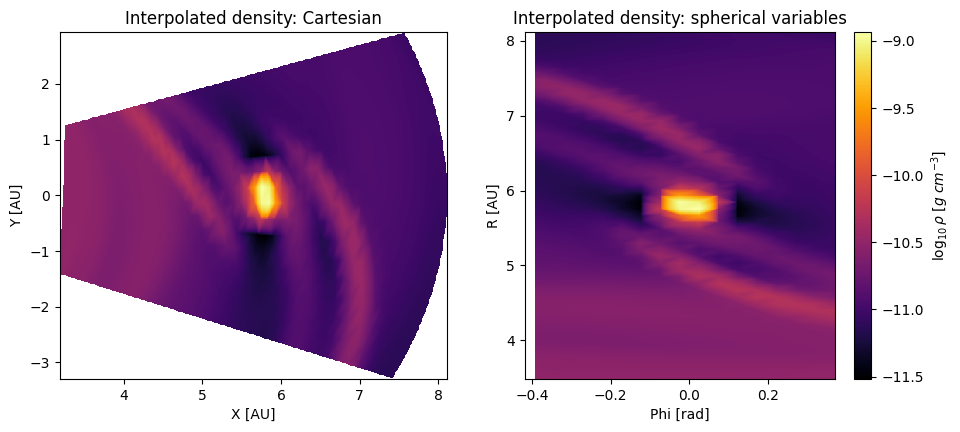

In [11]:
Xq_units = Xq * UL / sim.AU
Yq_units = Yq * UL / sim.AU
Rq_units = Rq * UL / sim.AU

rho_cartesian_units = rho_cartesian_interp * URHO
rho_spherical_units = rho_spherical_interp * URHO

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = ax[0].pcolormesh(
    Xq_units,
    Yq_units,
    np.log10(rho_cartesian_units),
    shading='auto',
    cmap='inferno',
)
ax[0].set_xlabel('X [AU]')
ax[0].set_ylabel('Y [AU]')
ax[0].set_title('Interpolated density: Cartesian')

im1 = ax[1].pcolormesh(
    PHIq,
    Rq_units,
    np.log10(rho_spherical_units),
    shading='auto',
    cmap='inferno',
)
ax[1].set_xlabel('Phi [rad]')
ax[1].set_ylabel('R [AU]')
ax[1].set_title('Interpolated density: spherical variables')
fig.colorbar(im1, ax=ax[1], label=r'$\log_{10}\rho~[g~cm^{-3}]$')
plt.show()


## 7. Add streamlines on a 2D slice

To add streamlines, load the velocity field in Cartesian coordinates and then interpolate it on a regular Cartesian grid.

For a midplane slice, use the `vx` and `vy` components.


Using griddata interpolation...
Using griddata interpolation...
Using griddata interpolation...


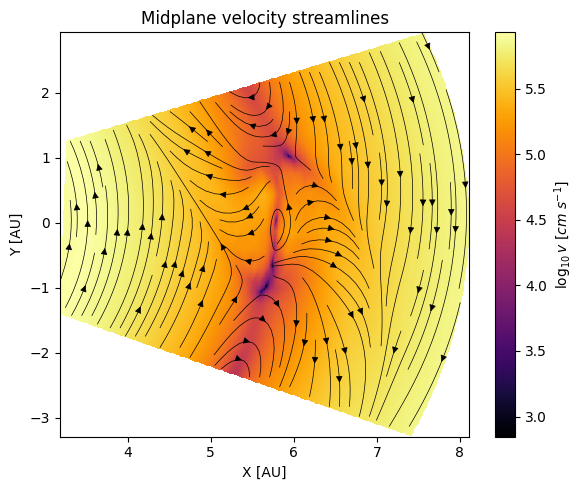

In [12]:
gasv_interp = fields_cartesian_slice.evaluate(
    field='gasv',
    var1=Xq,
    var2=Yq,
    snapshot=SNAP,
    coords='cartesian',
)

vx = gasv_interp[0]
vy = gasv_interp[1]
vmag = np.sqrt(vx**2 + vy**2)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.pcolormesh(
    Xq_units,
    Yq_units,
    np.log10(vmag * UV),
    shading='auto',
    cmap='inferno',
)

ax.streamplot(
    Xq_units,
    Yq_units,
    vx * UV,
    vy * UV,
    color='k',
    density=1.4,
    linewidth=0.5,
)

ax.set_xlabel('X [AU]')
ax.set_ylabel('Y [AU]')
ax.set_title('Midplane velocity streamlines')
fig.colorbar(im, ax=ax, label=r'$\log_{10}v~[cm~s^{-1}]$')
plt.tight_layout()
plt.show()


## 8. Meridional slice: XZ plane

A meridional slice can be obtained by fixing `phi`. For example:

```python
slice_meridional = 'phi=0,r=[0.6,1.4],theta=[1.40,pi/2]'
```

For the Cartesian representation of this slice, the useful plotting variables are usually `x` and `z`.


In [14]:
slice_meridional = 'phi=0,r=[0.8,1.2],theta=[1.40,pi/2]'

fields_cartesian_xz = sim.load_field(
    fields=fields,
    snapshot=SNAP,
    slice=slice_meridional,
    coords='cartesian',
)

fields_spherical_xz = sim.load_field(
    fields=fields,
    snapshot=SNAP,
    slice=slice_meridional,
    coords='spherical',
)


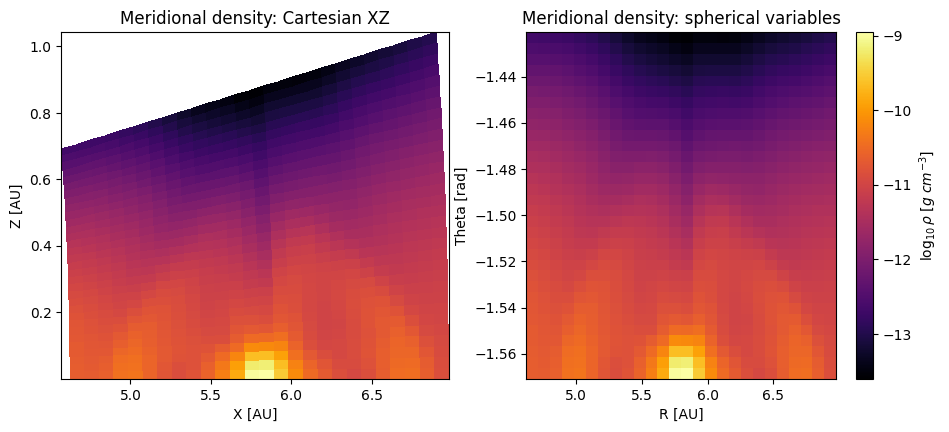

In [15]:
X_xz = fields_cartesian_xz.var1_mesh[0]
Z_xz = fields_cartesian_xz.var3_mesh[0]
RHO_xz = fields_cartesian_xz.gasdens_mesh[0]

R_xz = fields_spherical_xz.var2_mesh[0]
THETA_xz = fields_spherical_xz.var3_mesh[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = ax[0].pcolormesh(
    X_xz * UL / sim.AU,
    Z_xz * UL / sim.AU,
    np.log10(RHO_xz * URHO),
    shading='auto',
    cmap='inferno',
)
ax[0].set_xlabel('X [AU]')
ax[0].set_ylabel('Z [AU]')
ax[0].set_title('Meridional density: Cartesian XZ')


im1 = ax[1].pcolormesh(
    R_xz * UL / sim.AU,
    -THETA_xz,
    np.log10(RHO_xz * URHO),
    shading='auto',
    cmap='inferno',
)
ax[1].set_xlabel('R [AU]')
ax[1].set_ylabel('Theta [rad]')
ax[1].set_title('Meridional density: spherical variables')
fig.colorbar(im1, ax=ax[1], label=r'$\log_{10}\rho~[g~cm^{-3}]$')
plt.show()


## 9. Interpolate the meridional slice

For the Cartesian XZ slice, evaluate using:

- `var1 = x`
- `var3 = z`

The fixed coordinate `y` is inferred from the slice.

For the spherical meridional slice, evaluate using:

- `var2 = r`
- `var3 = theta`

The fixed coordinate `phi` is inferred from the slice.


In [16]:
RES_R = 500
RES_Z = 350

# Cartesian XZ query grid
xq = np.linspace(X_xz.min(), X_xz.max(), RES_R)
zq = np.linspace(Z_xz.min(), Z_xz.max(), RES_Z)
Xq_xz, Zq_xz = np.meshgrid(xq, zq)

rho_xz_cart_interp = fields_cartesian_xz.evaluate(
    field='gasdens',
    var1=Xq_xz,
    var3=Zq_xz,
    snapshot=SNAP,
    coords='cartesian',
)

# Spherical meridional query grid
rq = np.linspace(R_xz.min(), R_xz.max(), RES_R)
thetaq = np.linspace(THETA_xz.min(), THETA_xz.max(), RES_Z)
Rq_xz, THETAq_xz = np.meshgrid(rq, thetaq)

rho_xz_sph_interp = fields_spherical_xz.evaluate(
    field='gasdens',
    var2=Rq_xz,
    var3=THETAq_xz,
    snapshot=SNAP,
    coords='spherical',
)


Using griddata interpolation...
Using griddata interpolation...


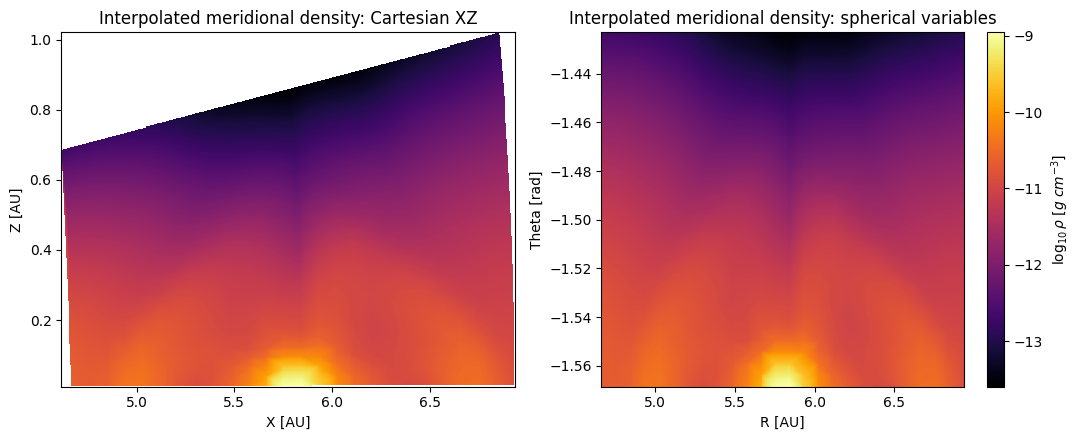

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = ax[0].pcolormesh(
    Xq_xz * UL / sim.AU,
    Zq_xz * UL / sim.AU,
    np.log10(rho_xz_cart_interp * URHO),
    shading='auto',
    cmap='inferno',
)
ax[0].set_xlabel('X [AU]')
ax[0].set_ylabel('Z [AU]')
ax[0].set_title('Interpolated meridional density: Cartesian XZ')


im1 = ax[1].pcolormesh(
    Rq_xz * UL / sim.AU,
    -THETAq_xz,
    np.log10(rho_xz_sph_interp * URHO),
    shading='auto',
    cmap='inferno',
)
ax[1].set_xlabel('R [AU]')
ax[1].set_ylabel('Theta [rad]')
ax[1].set_title('Interpolated meridional density: spherical variables')
fig.colorbar(im1, ax=ax[1], label=r'$\log_{10}\rho~[g~cm^{-3}]$')

plt.tight_layout()
plt.show()


## 10. Streamlines on the meridional slice

For a Cartesian XZ slice, use the `vx` and `vz` components of the velocity field.


Using griddata interpolation...
Using griddata interpolation...
Using griddata interpolation...


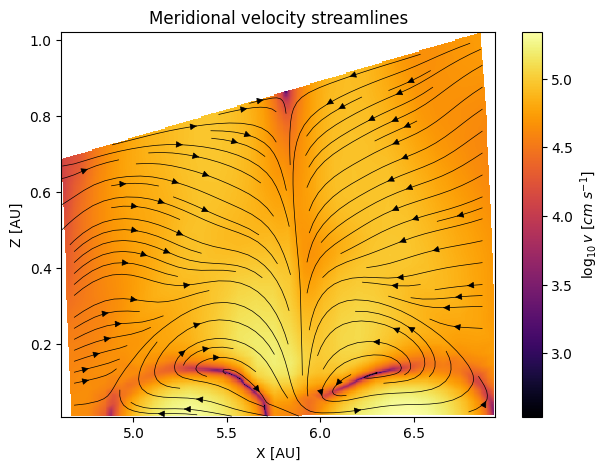

In [18]:
gasv_xz_interp = fields_cartesian_xz.evaluate(
    field='gasv',
    var1=Xq_xz,
    var3=Zq_xz,
    snapshot=SNAP,
    coords='cartesian',
)

vx_xz = gasv_xz_interp[0]
vz_xz = gasv_xz_interp[2]
vmag_xz = np.sqrt(vx_xz**2 + vz_xz**2)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.pcolormesh(
    Xq_xz * UL / sim.AU,
    Zq_xz * UL / sim.AU,
    np.log10(vmag_xz * UV),
    shading='auto',
    cmap='inferno',
)

ax.streamplot(
    Xq_xz * UL / sim.AU,
    Zq_xz * UL / sim.AU,
    vx_xz * UV,
    vz_xz * UV,
    color='k',
    density=1.2,
    linewidth=0.5,
)

ax.set_xlabel('X [AU]')
ax.set_ylabel('Z [AU]')
ax.set_title('Meridional velocity streamlines')
fig.colorbar(im, ax=ax, label=r'$\log_{10}v~[cm~s^{-1}]$')
plt.show()


## 11. Load the full 3D mesh

If no slice is provided, the full 3D mesh is loaded by default.

For large simulations this can be memory expensive. Start with a small number of fields and a low-resolution interpolation grid.


In [19]:
fields_3d_cartesian = sim.load_field(
    fields=['gasdens', 'gasv'],
    snapshot=SNAP,
    coords='cartesian',
)

fields_3d_spherical = sim.load_field(
    fields=['gasdens', 'gasv'],
    snapshot=SNAP,
    coords='spherical',
)


## 12. 3D interpolation in Cartesian coordinates

For Cartesian 3D interpolation:

* `var1 = x`
* `var2 = y`
* `var3 = z`

The following example builds a Cartesian box and evaluates the gas density inside it.

**Note:** Cartesian interpolation is useful for visualization and for querying data on Cartesian grids, but it is not the fastest option. For better performance, interpolate in the original coordinate system of the simulation. For the `p3disoj` simulation, this means spherical coordinates.


In [ ]:
NXYZ = 64

# Use the loaded Cartesian mesh to define a compact interpolation box.
X3 = fields_3d_cartesian.var1_mesh[0]
Y3 = fields_3d_cartesian.var2_mesh[0]
Z3 = fields_3d_cartesian.var3_mesh[0]

# A compact box around the planet position in code units.
# Adjust these limits for your own simulation.
xmin, xmax = 0.65, 1.35
ymin, ymax = -0.35, 0.35
zmin, zmax = max(Z3.min(), 0.0), min(Z3.max(), 0.25)

x = np.linspace(xmin, xmax, NXYZ)
y = np.linspace(ymin, ymax, NXYZ)
z = np.linspace(zmin, zmax, NXYZ)
Zq3_cart, Yq3_cart, Xq3_cart = np.meshgrid(z, y, x, indexing='ij')

rho_3d_cart = fields_3d_cartesian.evaluate(
    field='gasdens',
    var1=Xq3_cart,
    var2=Yq3_cart,
    var3=Zq3_cart,
    snapshot=SNAP,
    coords='cartesian',
)

print(rho_3d_cart.shape)
print(np.nanmin(rho_3d_cart * URHO), np.nanmax(rho_3d_cart * URHO))


Using griddata interpolation...


## 13. 3D interpolation in spherical coordinates (FASTER)

For spherical 3D interpolation:

- `var1 = phi`
- `var2 = r`
- `var3 = theta`

The following example evaluates the same density field directly in spherical variables.


In [20]:
NPHI = 64
NR = 64
NTHETA = 48

PHI3 = fields_3d_spherical.var1_mesh[0]
R3 = fields_3d_spherical.var2_mesh[0]
THETA3 = fields_3d_spherical.var3_mesh[0]

phi = np.linspace(-np.pi/8, np.pi/8, NPHI)
r = np.linspace(0.8, 1.2, NR)
theta = np.linspace(THETA3.min(), THETA3.max(), NTHETA)

THETAq3_sph, Rq3_sph, PHIq3_sph = np.meshgrid(theta, r, phi, indexing='ij')

rho_3d_sph = fields_3d_spherical.evaluate(
    field='gasdens',
    var1=PHIq3_sph,
    var2=Rq3_sph,
    var3=THETAq3_sph,
    snapshot=SNAP,
    coords='spherical',
)

print(rho_3d_sph.shape)


Using RegularGridInterpolator for 3D regular grid interpolation.
(48, 64, 64)


### Convert the spherical query grid to Cartesian coordinates for plotting

The interpolation was performed in spherical coordinates, but the visualization can still be shown in Cartesian space.


In [21]:
import numpy as np
import pyvista as pv
import fargopy as fp

# ------------------------------------------------------------
# Transform spherical interpolation mesh to Cartesian coordinates
# ------------------------------------------------------------
X_plot, Y_plot, Z_plot = fp.transform_coords(
    'spherical',
    'cartesian',
    PHIq3_sph,
    Rq3_sph,
    THETAq3_sph
)

# ------------------------------------------------------------
# Build PyVista structured grid
# ------------------------------------------------------------
grid = pv.StructuredGrid()

grid.dimensions = X_plot.shape

grid.points = np.column_stack([
    X_plot.ravel(order="F"),
    Y_plot.ravel(order="F"),
    -Z_plot.ravel(order="F")  # -Z to flip the vertical axis for better visualization
])

# Density field
grid["rho"] = rho_3d_sph.ravel(order="F")
grid["logrho"] = np.log10(grid["rho"])

# ------------------------------------------------------------
# Extract only the external surface of the 3D mesh
# ------------------------------------------------------------
surface = grid.extract_surface()

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plotter = pv.Plotter(notebook=True)

plotter.add_mesh(
    surface,
    scalars="logrho",
    cmap="inferno",
    show_edges=False,
    opacity=1.0,
    scalar_bar_args={
        "title": "log10 rho \n [g cm^-3]",
        "vertical": True
    }
)

plotter.add_axes()

plotter.show()


Dropped Escape call with ulEscapeCode : 0x03007703
Dropped Escape call with ulEscapeCode : 0x03007703
Dropped Escape call with ulEscapeCode : 0x03007703


Widget(value='<iframe src="http://localhost:36555/index.html?ui=P_0x70654b1020b0_0&reconnect=auto" class="pyvi…

## 14. Notes for large 3D simulations

For high-resolution 3D outputs, full-mesh loading and full-grid interpolation can become memory expensive.

Recommended workflow:

1. Start with 2D slices using `slice=...`.
2. Use compact spatial ranges such as `r=[0.8,1.2]`, `phi=[-pi/8,pi/8]` and `theta=[1.45,pi/2]`.
3. For full 3D interpolation, use original coordinates of the sim.
4. Load only the fields needed for the plot.
5. For streamlines, load `gasv` with `coords='cartesian'` and interpolate on a regular Cartesian grid.


### Bonus: Plotly surface plot

In [25]:
import numpy as np
import plotly.graph_objects as go

# ------------------------------------------------------------
# Input arrays
# ------------------------------------------------------------
X_plot = np.asarray(X_plot)
Y_plot = np.asarray(Y_plot)
Z_plot = np.asarray(Z_plot)
rho_plot = np.asarray(rho_3d_sph)

assert X_plot.shape == Y_plot.shape == Z_plot.shape == rho_plot.shape

logrho = np.log10(rho_plot + 1e-300)

cmin = np.nanmin(logrho)
cmax = np.nanmax(logrho)

# ------------------------------------------------------------
# Helper function to add one external surface
# ------------------------------------------------------------
def add_surface(fig, Xs, Ys, Zs, Cs, name, showscale=False):
    fig.add_trace(go.Surface(
        x=Xs,
        y=Ys,
        z=-Zs,
        surfacecolor=Cs,
        colorscale="Inferno",
        cmin=cmin,
        cmax=cmax,
        showscale=showscale,
        colorbar=dict(
            title=r"log10 rho [g cm^-3]"
        ) if showscale else None,
        opacity=1.0,
        name=name,
        showlegend=False
    ))

# ------------------------------------------------------------
# Plot only the external faces of the structured 3D mesh
# ------------------------------------------------------------
fig = go.Figure()

# First coordinate boundary: theta min / z min
add_surface(
    fig,
    X_plot[0, :, :],
    Y_plot[0, :, :],
    Z_plot[0, :, :],
    logrho[0, :, :],
    name="axis 0 min",
    showscale=True
)

# First coordinate boundary: theta max / z max
add_surface(
    fig,
    X_plot[-1, :, :],
    Y_plot[-1, :, :],
    Z_plot[-1, :, :],
    logrho[-1, :, :],
    name="axis 0 max"
)

# Radial inner boundary
add_surface(
    fig,
    X_plot[:, 0, :],
    Y_plot[:, 0, :],
    Z_plot[:, 0, :],
    logrho[:, 0, :],
    name="r min"
)

# Radial outer boundary
add_surface(
    fig,
    X_plot[:, -1, :],
    Y_plot[:, -1, :],
    Z_plot[:, -1, :],
    logrho[:, -1, :],
    name="r max"
)

# Azimuthal boundary phi min
add_surface(
    fig,
    X_plot[:, :, 0],
    Y_plot[:, :, 0],
    Z_plot[:, :, 0],
    logrho[:, :, 0],
    name="phi min"
)

# Azimuthal boundary phi max
add_surface(
    fig,
    X_plot[:, :, -1],
    Y_plot[:, :, -1],
    Z_plot[:, :, -1],
    logrho[:, :, -1],
    name="phi max"
)

fig.update_layout(
    title="External surface of the 3D interpolation mesh",
    scene=dict(
        xaxis_title="X [AU]",
        yaxis_title="Y [AU]",
        zaxis_title="Z [AU]",
        aspectmode="data"
    ),
    width=850,
    height=750
)

fig.show()

---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
